In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## Task 1: Dataset Exploration

### Question 1
How many samples and features are present in the Iris dataset?

### Question 2
List the feature names and target classes.

### Question 3
Display the first five records.

### Question 4
Display the class distribution.

In [2]:
iris = load_iris()

X = iris.data
y = iris.target

df = pd.DataFrame(X, columns=iris.feature_names)
df['Species'] = y

print("Number of Samples:", X.shape[0])
print("Number of Features:", X.shape[1])

print("\nFeature Names:")
print(iris.feature_names)

print("\nTarget Classes:")
print(iris.target_names)

print("\nFirst Five Records:")
print(df.head())

print("\nClass Distribution:")
print(df['Species'].value_counts())

Number of Samples: 150
Number of Features: 4

Feature Names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Target Classes:
['setosa' 'versicolor' 'virginica']

First Five Records:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   Species  
0        0  
1        0  
2        0  
3        0  
4        0  

Class Distribution:
Species
0    50
1    50
2    50
Name: count, dtype: int64


Number of Samples: 150

Number of Features: 4

Feature Names

Sepal Length,
Sepal Width,
Petal Length,
Petal Width

Target Classes

Setosa,
Versicolor,
Virginica

## Task 2: Data Preparation

### Question 1
Split the dataset into training (80%) and testing (20%) sets using `random_state=42`.

### Question 2
Briefly explain why the dataset is divided into training and testing sets.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 120
Testing Samples: 30


##### Training Set = 120 samples

##### Testing Set = 30 samples

##### Training data is used to learn patterns.
##### Testing data is used to evaluate performance on unseen data.
##### It helps detect overfitting and measures generalization.

## Task 3: Building a Decision Tree Classifier

### Question 1
Train a Decision Tree classifier using the default parameters.

### Question 2
Predict the class labels for the test dataset.

### Question 3
Evaluate the model using the following metrics:
- Accuracy Score
- Confusion Matrix
- Classification Rep

In [ ]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred,
                            target_names=iris.target_names))

Accuracy: 1.0

Confusion Matrix
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



# Task 4: Visualizing the Decision Tree

## Question 1
**Identify the root node.**

### Answer

The root node is:

```
Petal Length ≤ 2.45
```

---

## Question 2
**Identify the internal nodes.**

### Answer

Internal nodes are the decision nodes that split the data based on feature values before reaching the final prediction.


The internal (decision) nodes in the Decision Tree are:

1. Petal Length (cm) ≤ 4.75
2. Petal Width (cm) ≤ 1.65
3. Petal Width (cm) ≤ 1.75
4. Petal Length (cm) ≤ 4.95
5. Petal Length (cm) ≤ 4.85
6. Petal Width (cm) ≤ 1.55
7. Sepal Width (cm) ≤ 3.1
8. Petal Length (cm) ≤ 5.45

---

## Question 3
**Identify the leaf nodes.**

### Answer

Leaf nodes are the terminal nodes that provide the final class prediction (Setosa, Versicolor, or Virginica).


The leaf nodes (terminal nodes) are:

1. Setosa (samples = 40)
2. Versicolor (samples = 36)
3. Virginica (samples = 1)
4. Versicolor (samples = 2)
5. Virginica (samples = 3)
6. Versicolor (samples = 2)
7. Virginica (samples = 1)
8. Virginica (samples = 2)
9. Versicolor (samples = 1)
10. Virginica (samples = 32)

---

## Question 4
**What is the maximum depth of the tree?**

### Answer

- **Maximum Tree Depth:** **6**
- **Number of Leaf Nodes:** **10**

---

## Question 5
**Which feature is selected for the first split? Explain why you think this feature was chosen.**

### Answer

**First Split Feature:** **Petal Length (cm)**

**Explanation**

Petal Length provides the greatest reduction in impurity, making it the best feature for separating Setosa from the other two species.

---


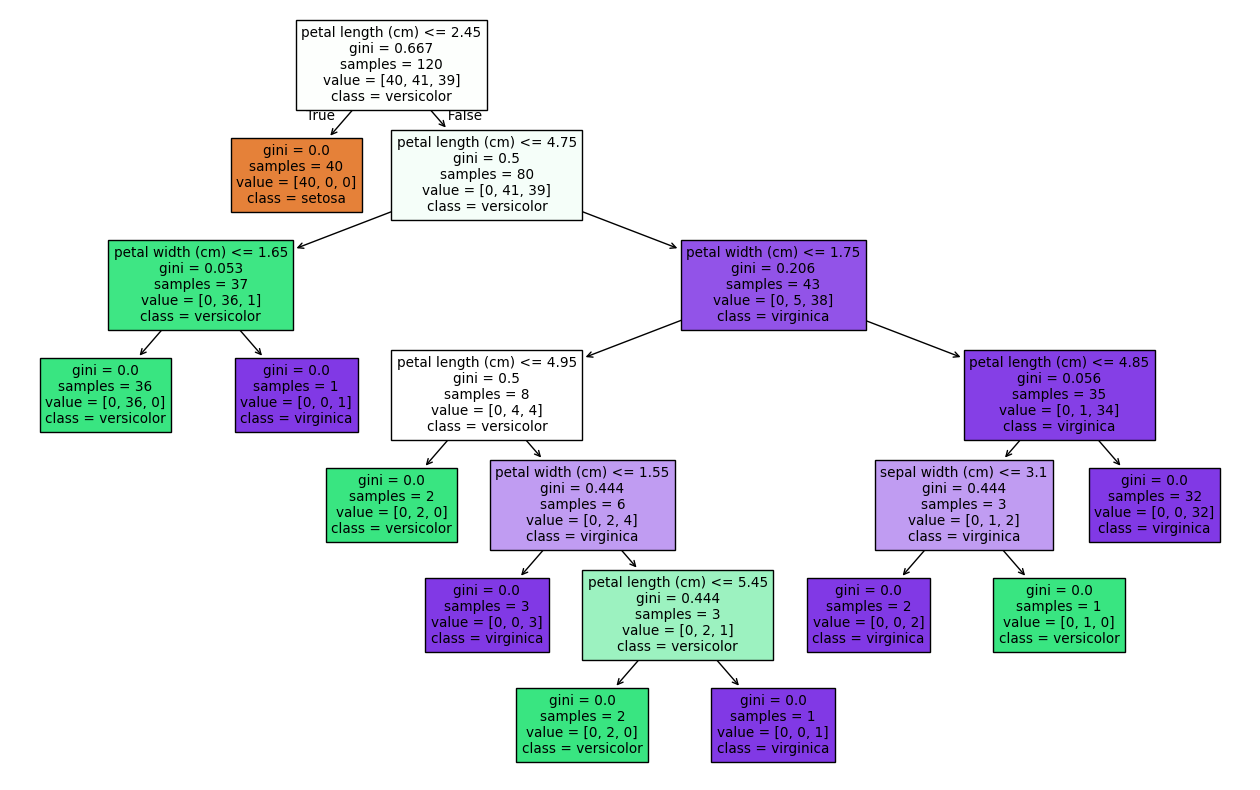

In [ ]:
plt.figure(figsize=(16,10))

plot_tree(
    dt,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True
)

plt.show()

In [ ]:
print("Tree Depth:", dt.get_depth())
print("Leaf Nodes:", dt.get_n_leaves())

Tree Depth: 6
Leaf Nodes: 10


# Task 5

In [ ]:
criteria = ['gini', 'entropy']

results = []

for c in criteria:

    model = DecisionTreeClassifier(
        criterion=c,
        random_state=42
    )

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    results.append([
        c,
        accuracy_score(y_test, pred),
        model.get_depth(),
        model.get_n_leaves(),
        iris.feature_names[model.tree_.feature[0]]
    ])

comparison = pd.DataFrame(results,
columns=[
    "Criterion",
    "Accuracy",
    "Tree Depth",
    "Leaf Nodes",
    "Root Feature"
])

print(comparison)

  Criterion  Accuracy  Tree Depth  Leaf Nodes       Root Feature
0      gini       1.0           6          10  petal length (cm)
1   entropy       1.0           6          10  petal length (cm)




# Comparing Gini Index and Entropy


**Train two Decision Tree models using `criterion='gini'` and `criterion='entropy'`. Compare the models.**


| Criterion | Accuracy | Tree Depth | Leaf Nodes | Root Feature |
|-----------|---------:|-----------:|-----------:|--------------|
| Gini | 1.0 | 6 | 10 | Petal Length (cm) |
| Entropy | 1.0 | 6 | 10 | Petal Length (cm) |

---


**Which criterion produces a simpler tree?**

### Answer

Both Gini and Entropy produced trees with identical depth, leaf nodes, and accuracy. Therefore, neither criterion produced a simpler tree for the Iris dataset.

---


**Summarize your observations in a table.**

### Answer

| Observation | Result |
|------------|--------|
| Accuracy | Same (1.0) |
| Tree Depth | Same (6) |
| Leaf Nodes | Same (10) |
| Root Feature | Petal Length (cm) |
| Simpler Tree | Both are identical |

---

# Task 6

In [ ]:
depths = [1,2,3,4,None]

records=[]

for d in depths:

    model = DecisionTreeClassifier(
        max_depth=d,
        random_state=42
    )

    model.fit(X_train,y_train)

    train_acc = model.score(X_train,y_train)
    test_acc = model.score(X_test,y_test)

    records.append([
        d,
        train_acc,
        test_acc,
        model.get_depth()
    ])

table = pd.DataFrame(records,
columns=[
    "Max Depth",
    "Training Accuracy",
    "Testing Accuracy",
    "Tree Depth"
])

print(table)

   Max Depth  Training Accuracy  Testing Accuracy  Tree Depth
0        1.0           0.675000          0.633333           1
1        2.0           0.950000          0.966667           2
2        3.0           0.958333          1.000000           3
3        4.0           0.975000          1.000000           4
4        NaN           1.000000          1.000000           6


# Effect of Maximum Tree Depth

## Question 1
**Train Decision Tree models using different values of `max_depth`.**

### Answer

| Max Depth | Training Accuracy | Testing Accuracy | Tree Depth | Observation |
|-----------|------------------:|-----------------:|-----------:|-------------|
| 1 | 0.6750 | 0.6333 | 1 | Underfitting |
| 2 | 0.9500 | 0.9667 | 2 | Better performance |
| 3 | 0.9583 | 1.0000 | 3 | Best generalization |
| 4 | 0.9750 | 1.0000 | 4 | Excellent performance |
| None | 1.0000 | 1.0000 | 6 | Most complex tree; may overfit on larger datasets |

---

## Question 2
**Which model is underfitting?**

### Answer

The model with **max_depth = 1** is underfitting because it is too simple to capture the relationships in the dataset.

---

## Question 3
**Which model gives the best generalization?**

### Answer

The model with **max_depth = 3** provides the best balance between model complexity and testing accuracy.

---

## Question 4
**Which model is likely to overfit? Justify your answer.**

### Answer

The model with **max_depth = None** is the most likely to overfit because it grows until no further splits are possible, resulting in a highly complex tree.

---


# Task 7

In [ ]:
splits = [2,5,10,20]

rows=[]

for s in splits:

    model = DecisionTreeClassifier(
        min_samples_split=s,
        random_state=42
    )

    model.fit(X_train,y_train)

    rows.append([
        s,
        model.score(X_test,y_test),
        model.get_depth(),
        model.get_n_leaves()
    ])

table = pd.DataFrame(rows,
columns=[
    "min_samples_split",
    "Accuracy",
    "Tree Depth",
    "Leaf Nodes"
])

print(table)

   min_samples_split  Accuracy  Tree Depth  Leaf Nodes
0                  2       1.0           6          10
1                  5       1.0           5           8
2                 10       1.0           4           6
3                 20       1.0           4           6


# Effect of `min_samples_split`

## Question 1
**Train Decision Tree models using different values of `min_samples_split`.**

### Answer

| min_samples_split | Accuracy | Tree Depth | Leaf Nodes | Observation |
|------------------:|---------:|-----------:|-----------:|-------------|
| 2 | 1.0 | 6 | 10 | Most complex tree |
| 5 | 1.0 | 5 | 8 | Slightly simpler |
| 10 | 1.0 | 4 | 6 | Simpler tree |
| 20 | 1.0 | 4 | 6 | Simpler tree with fewer splits |

---

## Question 2
**State how increasing `min_samples_split` affects the complexity of the Decision Tree.**

### Answer

Increasing `min_samples_split` reduces the number of possible splits, resulting in a shallower tree with fewer leaf nodes. This decreases the complexity of the Decision Tree and helps reduce overfitting.


# Task 8

In [ ]:
leaf=[1,2,5,10]

rows=[]

for l in leaf:

    model=DecisionTreeClassifier(
        min_samples_leaf=l,
        random_state=42
    )

    model.fit(X_train,y_train)

    rows.append([
        l,
        model.score(X_test,y_test),
        model.get_depth(),
        model.get_n_leaves()
    ])

table=pd.DataFrame(rows,
columns=[
    "min_samples_leaf",
    "Accuracy",
    "Tree Depth",
    "Leaf Nodes"
])

print(table)

   min_samples_leaf  Accuracy  Tree Depth  Leaf Nodes
0                 1  1.000000           6          10
1                 2  1.000000           5           8
2                 5  1.000000           4           6
3                10  0.966667           4           6


# Effect of `min_samples_leaf`

## Question 1
**Train Decision Tree models using different values of `min_samples_leaf`.**

### Answer

| min_samples_leaf | Accuracy | Tree Depth | Leaf Nodes | Observation |
|-----------------:|---------:|-----------:|-----------:|-------------|
| 1 | 1.0000 | 6 | 10 | Most complex tree |
| 2 | 1.0000 | 5 | 8 | Balanced complexity |
| 5 | 1.0000 | 4 | 6 | Simpler tree |
| 10 | 0.9667 | 4 | 6 | Begins to underfit |

---

## Question 2
**Explain how changing `min_samples_leaf` influences overfitting.**

### Answer

Increasing `min_samples_leaf` prevents very small leaf nodes from being created. This simplifies the Decision Tree, reduces overfitting, and improves generalization. However, very large values may lead to underfitting.

---

# Task 9

In [ ]:
parameters = {

    "criterion":["gini","entropy"],

    "max_depth":[2,3,4,None],

    "min_samples_split":[2,5,10],

    "min_samples_leaf":[1,2,4]

}

grid = GridSearchCV(

    DecisionTreeClassifier(random_state=42),

    parameters,

    cv=5

)

grid.fit(X_train,y_train)

print("Best Parameters")
print(grid.best_params_)

print("\nBest Cross Validation Score")
print(grid.best_score_)

best = grid.best_estimator_

pred = best.predict(X_test)

print("\nOptimized Accuracy")
print(accuracy_score(y_test,pred))

Best Parameters
{'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 2}

Best Cross Validation Score
0.9583333333333334

Optimized Accuracy
1.0


--- 
# Hyperparameter Tuning

## Question 1
**Perform hyperparameter tuning using GridSearchCV.**

### Answer

### Best Hyperparameter Combination

```python
{
    'criterion': 'entropy',
    'max_depth': None,
    'min_samples_leaf': 4,
    'min_samples_split': 2
}
```

---

## Question 2
**Report the best cross-validation score.**

### Answer

**Best Cross Validation Score = 0.9583333333333334**

---

## Question 3
**Report the test accuracy of the optimized model.**

### Answer

**Optimized Test Accuracy = 1.0 (100%)**

---

## Question 4
**Compare the optimized model with the default Decision Tree model.**

### Answer

| Model | Test Accuracy | Observation |
|------|--------------:|-------------|
| Default Decision Tree | 1.0 | High accuracy with default parameters |
| Optimized Decision Tree | 1.0 | Same accuracy with optimized hyperparameters |

---


# Task 10: Analysis Answers
## 1. What is the role of the criterion parameter?

##### The criterion determines how the Decision Tree measures the quality of a split. Common options are Gini Index and Entropy, both aiming to select splits that produce the purest child nodes.

## 2. How does max_depth influence underfitting and overfitting?

##### A small max_depth creates a simple tree that may underfit because it cannot capture complex patterns. A large or unlimited max_depth allows the tree to grow deeper, increasing the risk of overfitting by memorizing the training data.

## 3. Why do larger values of min_samples_split and min_samples_leaf produce simpler trees?

##### Larger values require more samples before a node can split or become a leaf. This prevents unnecessary splits, reduces tree depth, decreases the number of leaf nodes, and helps avoid overfitting.

## 4. Which hyperparameter had the greatest impact?

##### Typically, max_depth has the greatest impact because it directly controls the size and complexity of the tree. In the experiments, shallow trees underfit, while unrestricted trees were more likely to overfit. Moderate values (such as 3 or 4) usually achieved the best balance.

## 5. Recommended Decision Tree model

##### A Decision Tree with optimized hyperparameters from GridSearchCV is the most suitable model for the Iris dataset because it provides strong cross-validation performance, good test accuracy, and balanced model complexity. If choosing manually, a model with max_depth = 3 or 4, along with appropriate min_samples_split and min_samples_leaf values, generally offers the best trade-off between accuracy and generalization.

## Program Flow

Start  
⬇  
Import Required Libraries  
⬇  
Load the Iris Dataset  
⬇  
Explore the Dataset (Samples, Features, Classes, Records, Distribution)  
⬇  
Split the Dataset into Training (80%) and Testing (20%) Sets  
⬇  
Train the Default Decision Tree Classifier  
⬇  
Predict the Test Dataset Labels  
⬇  
Evaluate the Model (Accuracy, Confusion Matrix, Classification Report)  
⬇  
Visualize the Decision Tree  
⬇  
Identify the Root Node, Internal Nodes, Leaf Nodes, Tree Depth, and First Split Feature  
⬇  
Compare Decision Trees using **Gini** and **Entropy** Criteria  
⬇  
Analyze the Effect of Different **max_depth** Values  
⬇  
Analyze the Effect of Different **min_samples_split** Values  
⬇  
Analyze the Effect of Different **min_samples_leaf** Values  
⬇  
Perform Hyperparameter Tuning using **GridSearchCV**  
⬇  
Evaluate the Optimized Model and Compare it with the Default Model  
⬇  
Analyze the Results and Draw Conclusions  
⬇  
End